# Initial EDA

## Datasets
1. **BLS Average Price** — monthly prices for selected goods (`Dataset #2 - inflation.txt`)
2. **BLS Employment, Hours & Earnings** — monthly employment series by industry (`Dataset #1 - earnings.txt`)
3. **Zillow Observed Rent Index** — monthly rent index by metro (`Dataset #3 - Metro_zori_uc_sfrcondomfr_sm_month.csv`)

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1. Inflation (BLS Average Price)

In [8]:
labels = {}
with open('inflation_ids.txt') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        label, code = line.rsplit(' - ', 1)
        labels[code.strip()] = label.strip()

df = pd.read_csv('Dataset #2 - inflation.txt')
df = df.rename(columns={'Series ID': 'series_id'})
df['item'] = df['series_id'].map(labels)
print(df.shape)
df[['series_id', 'item']]

(15, 134)


,series_id,item
0,APU0000704111,"Bacon, sliced, per lb."
1,APU0000711211,"Bananas, per lb."
2,APU0000702111,"Bread, white, pan, per lb."
3,APU0000706111,"Chicken, fresh, whole, per lb."
4,APU0000717311,"Coffee, 100%, ground roast, all sizes, per lb."
5,APU0000708111,"Eggs, grade A, large, per doz."
6,APU0000701111,"Flour, white, all purpose, per lb."
7,APU0000709112,"Milk, fresh, whole, fortified, per gal."
8,APU0000711311,"Oranges, navel, per lb."
9,APU0000701312,"Rice, white, long grain, uncooked, per lb."


In [9]:
# Wide -> long, parse dates, coerce non-numeric placeholders like '-(X)' and blanks to NaN.
inf_long = df.melt(id_vars=['series_id', 'item'], var_name='month', value_name='price')
inf_long['month'] = pd.to_datetime(inf_long['month'], format='%b %Y', errors='coerce')
inf_long['price'] = pd.to_numeric(inf_long['price'], errors='coerce')
inf_long = inf_long.dropna(subset=['month', 'price'])

print('rows:', len(inf_long))
print('date range:', inf_long['month'].min().date(), '->', inf_long['month'].max().date())
inf_long.head(25)

rows: 1814
date range: 2016-01-01 -> 2026-04-01


,series_id,item,month,price
0,APU0000704111,"Bacon, sliced, per lb.",2016-01-01,5.656
1,APU0000711211,"Bananas, per lb.",2016-01-01,0.581
2,APU0000702111,"Bread, white, pan, per lb.",2016-01-01,1.425
3,APU0000706111,"Chicken, fresh, whole, per lb.",2016-01-01,1.429
4,APU0000717311,"Coffee, 100%, ground roast, all sizes, per lb.",2016-01-01,4.498
5,APU0000708111,"Eggs, grade A, large, per doz.",2016-01-01,2.328
6,APU0000701111,"Flour, white, all purpose, per lb.",2016-01-01,0.522
7,APU0000709112,"Milk, fresh, whole, fortified, per gal.",2016-01-01,3.313
8,APU0000711311,"Oranges, navel, per lb.",2016-01-01,1.196
9,APU0000701312,"Rice, white, long grain, uncooked, per lb.",2016-01-01,0.709


In [11]:
# monthly observations per item
inf_long.groupby('item').size().sort_values()

item
Coffee, 100%, ground roast, all sizes, per lb.    108
Oranges, navel, per lb.                           111
Tomatoes, field grown, per lb.                    121
Chicken, fresh, whole, per lb.                    122
Flour, white, all purpose, per lb.                122
Rice, white, long grain, uncooked, per lb.        122
Bread, white, pan, per lb.                        123
Bacon, sliced, per lb.                            123
Electricity per KWH                               123
Eggs, grade A, large, per doz.                    123
Bananas, per lb.                                  123
Fuel oil #2 per gallon                            123
Gasoline, all types, per gallon                   123
Milk, fresh, whole, fortified, per gal.           123
Gasoline, unleaded regular, per gallon            124
dtype: int64

In [17]:
# normalize each item to its Jan-2016 value to compare growth on one axis
base = (inf_long.sort_values('month').groupby('item').first()['price'].rename('base'))
base

item
Bacon, sliced, per lb.                            5.656
Bananas, per lb.                                  0.581
Bread, white, pan, per lb.                        1.425
Chicken, fresh, whole, per lb.                    1.429
Coffee, 100%, ground roast, all sizes, per lb.    4.498
Eggs, grade A, large, per doz.                    2.328
Electricity per KWH                               0.134
Flour, white, all purpose, per lb.                0.522
Fuel oil #2 per gallon                            1.970
Gasoline, all types, per gallon                   2.034
Gasoline, unleaded regular, per gallon            1.967
Milk, fresh, whole, fortified, per gal.           3.313
Oranges, navel, per lb.                           1.196
Rice, white, long grain, uncooked, per lb.        0.709
Tomatoes, field grown, per lb.                    2.528
Name: base, dtype: float64

In [26]:
# fill the normalized growth per item over the 10 years
inf_idx = inf_long.join(base, on='item')
inf_idx['index_100'] = 100 * inf_idx['price'] / inf_idx['base']\

inf_idx[inf_idx['series_id'] == "APU0000704111"]

,series_id,item,month,price,base,index_100
0,APU0000704111,"Bacon, sliced, per lb.",2016-01-01,5.656,5.656,100.000000
15,APU0000704111,"Bacon, sliced, per lb.",2016-02-01,5.394,5.656,95.367751
30,APU0000704111,"Bacon, sliced, per lb.",2016-03-01,5.494,5.656,97.135785
45,APU0000704111,"Bacon, sliced, per lb.",2016-04-01,5.613,5.656,99.239745
60,APU0000704111,"Bacon, sliced, per lb.",2016-05-01,5.552,5.656,98.161245
...,...,...,...,...,...,...
1785,APU0000704111,"Bacon, sliced, per lb.",2025-12-01,6.760,5.656,119.519095
1800,APU0000704111,"Bacon, sliced, per lb.",2026-01-01,6.978,5.656,123.373409
1815,APU0000704111,"Bacon, sliced, per lb.",2026-02-01,6.904,5.656,122.065064
1830,APU0000704111,"Bacon, sliced, per lb.",2026-03-01,6.801,5.656,120.243989


0       100.000000
1       100.000000
2       100.000000
3       100.000000
4       100.000000
           ...    
1855    106.368671
1856    144.776119
1857    268.578680
1858    216.764995
1859    216.725979
Name: index_100, Length: 1814, dtype: float64


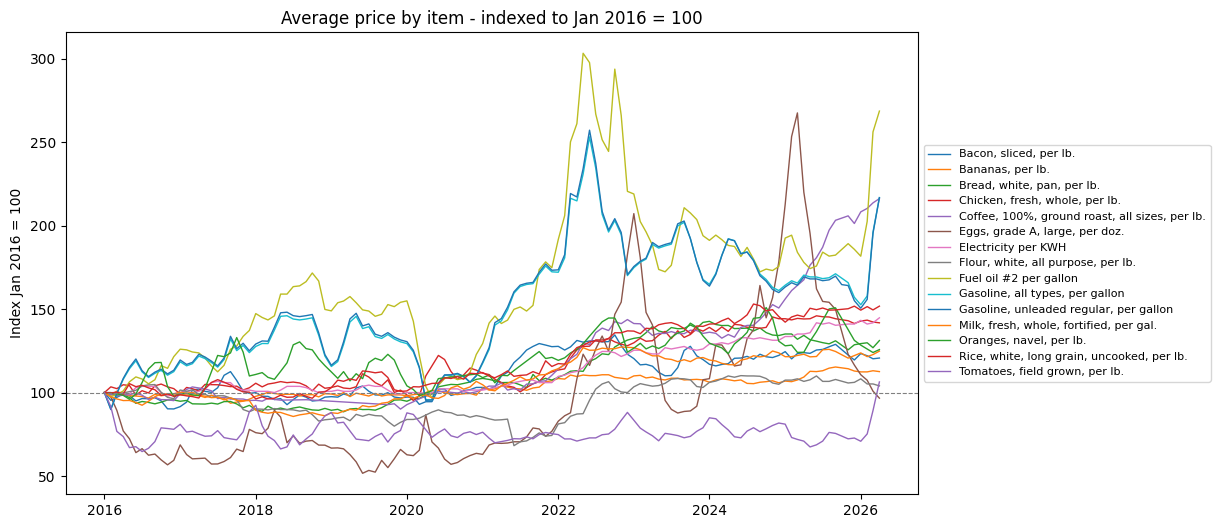

In [ ]:


fig, ax = plt.subplots(figsize=(11, 6))
for item, grp in inf_idx.groupby('item'):
    ax.plot(grp['month'], grp['index_100'], label=item, linewidth=1)
ax.axhline(100, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Average price by item - indexed to Jan 2016 = 100')
ax.set_ylabel('Index Jan 2016 = 100')
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8)
plt.show()

## 2. Earnings BLS CES

Numbers are in thousands. Series prefixed `CEU` = not seasonally adjusted, `CES` = seasonally adjusted. The first two rows are total nonfarm

In [36]:
earn = pd.read_csv('Dataset #1 - earnings.txt')
earn = earn.rename(columns={'Series ID': 'series_id'})
print(earn.shape)
earn['series_id'].head(10).tolist()

(348, 133)


['CEU0000000001',
 'CES0000000001',
 'CEU0500000001',
 'CES0500000001',
 'CEU0600000001',
 'CES0600000001',
 'CEU1000000001',
 'CES1000000001',
 'CEU1011330001',
 'CES1011330001']

In [42]:
earn_long = earn.melt(id_vars=['series_id'], var_name='month', value_name='employment')
earn_long['month'] = pd.to_datetime(earn_long['month'], format='%b %Y', errors='coerce')
earn_long

,series_id,month,employment
0,CEU0000000001,2016-01-01,141073.0
1,CES0000000001,2016-01-01,143210.0
2,CEU0500000001,2016-01-01,119093.0
3,CES0500000001,2016-01-01,121096.0
4,CEU0600000001,2016-01-01,19238.0
...,...,...,...
45931,CES9093000001,2026-12-01,
45932,CEU9093161101,2026-12-01,
45933,CES9093161101,2026-12-01,
45934,CEU9093200001,2026-12-01,


In [45]:
earn_long[earn_long['series_id'] == 'CEU0000000001']

,series_id,month,employment,adjusted
0,CEU0000000001,2016-01-01,141073.0,False
348,CEU0000000001,2016-02-01,141900.0,False
696,CEU0000000001,2016-03-01,142797.0,False
1044,CEU0000000001,2016-04-01,143892.0,False
1392,CEU0000000001,2016-05-01,144541.0,False
...,...,...,...,...
41412,CEU0000000001,2025-12-01,159358.0,False
41760,CEU0000000001,2026-01-01,156728.0,False
42108,CEU0000000001,2026-02-01,157214.0,False
42456,CEU0000000001,2026-03-01,157769.0,False


In [43]:
# Some values are tagged with '(P)' for preliminary so strip and coerce
earn_long['employment'] = pd.to_numeric(earn_long['employment'].astype(str).str.replace(r'\(P\)', '', regex=True).str.strip())
earn_long = earn_long.dropna(subset=['month', 'employment'])
earn_long['adjusted'] = earn_long['series_id'].str.startswith('CES')
earn_long.head()

C:\Users\gjo57\AppData\Local\Temp\ipykernel_43896\3141838733.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  earn_long['adjusted'] = earn_long['series_id'].str.startswith('CES')


,series_id,month,employment,adjusted
0,CEU0000000001,2016-01-01,141073.0,False
1,CES0000000001,2016-01-01,143210.0,True
2,CEU0500000001,2016-01-01,119093.0,False
3,CES0500000001,2016-01-01,121096.0,True
4,CEU0600000001,2016-01-01,19238.0,False


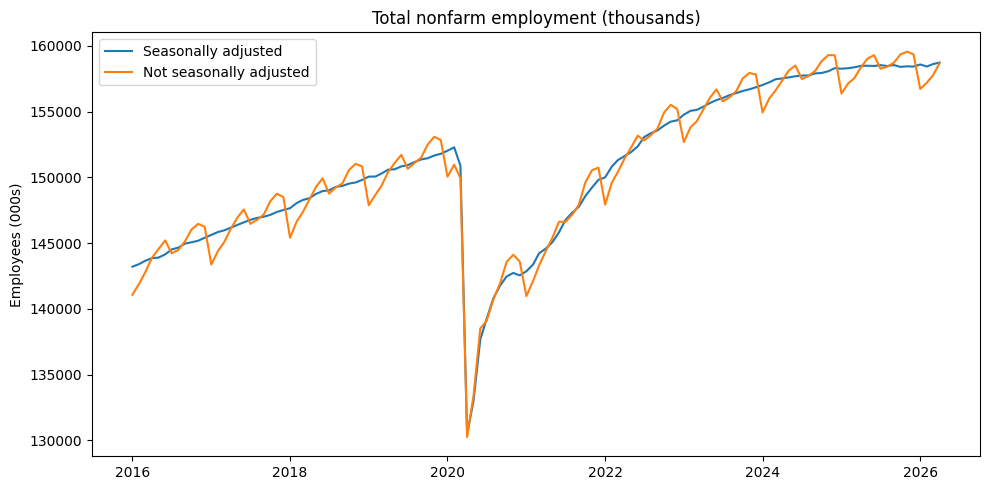

In [44]:
# Total nonfarm employment, SA vs NSA.
total = earn_long[earn_long['series_id'].isin(['CEU0000000001', 'CES0000000001'])]

fig, ax = plt.subplots(figsize=(10, 5))
for sid, grp in total.groupby('series_id'):
    label = 'Seasonally adjusted' if sid.startswith('CES') else 'Not seasonally adjusted'
    ax.plot(grp['month'], grp['employment'], label=label)
ax.set_title('Total nonfarm employment (thousands)')
ax.set_ylabel('Employees (000s)')
ax.legend()
fig.tight_layout()
plt.show()

## 3. Rent (Zillow Observed Rent Index)

Monthly rent index by metro, plus a United States row. We'll use the US row as a headline trend.

In [37]:
rent = pd.read_csv('Dataset #3 - Metro_zori_uc_sfrcondomfr_sm_month.csv')
id_cols = ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName']
print(rent.shape)
print('regions:', rent['RegionName'].nunique())
rent[id_cols].head()

(720, 141)
regions: 720


,RegionID,SizeRank,RegionName,RegionType,StateName
0,102001,0,United States,country,NaN
1,394913,1,"New York, NY",msa,NY
2,753899,2,"Los Angeles, CA",msa,CA
3,394463,3,"Chicago, IL",msa,IL
4,394514,4,"Dallas, TX",msa,TX


In [38]:
rent_long = rent.melt(id_vars=id_cols, var_name='month', value_name='zori')
rent_long['month'] = pd.to_datetime(rent_long['month'], errors='coerce')
rent_long = rent_long.dropna(subset=['month', 'zori'])
rent_long.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,month,zori
0,102001,0,United States,country,NaN,2015-01-31,1142.150088
1,394913,1,"New York, NY",msa,NY,2015-01-31,2208.053897
2,753899,2,"Los Angeles, CA",msa,CA,2015-01-31,1730.517939
3,394463,3,"Chicago, IL",msa,IL,2015-01-31,1387.825224
4,394514,4,"Dallas, TX",msa,TX,2015-01-31,1054.190026


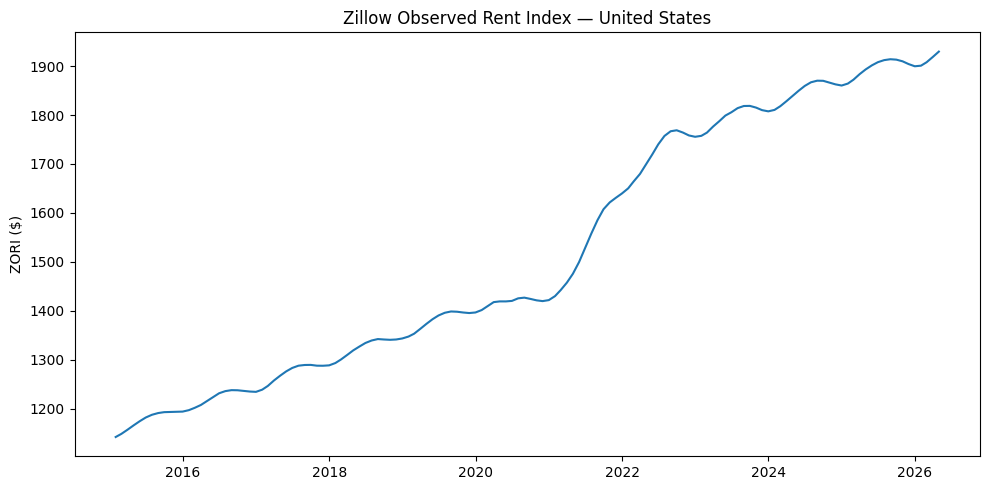

In [39]:
us = rent_long[rent_long['RegionName'] == 'United States']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(us['month'], us['zori'])
ax.set_title('Zillow Observed Rent Index — United States')
ax.set_ylabel('ZORI ($)')
fig.tight_layout()
plt.show()

## Quick overlay

All three series rebased to Jan 2016 = 100 so they can be compared on one axis.

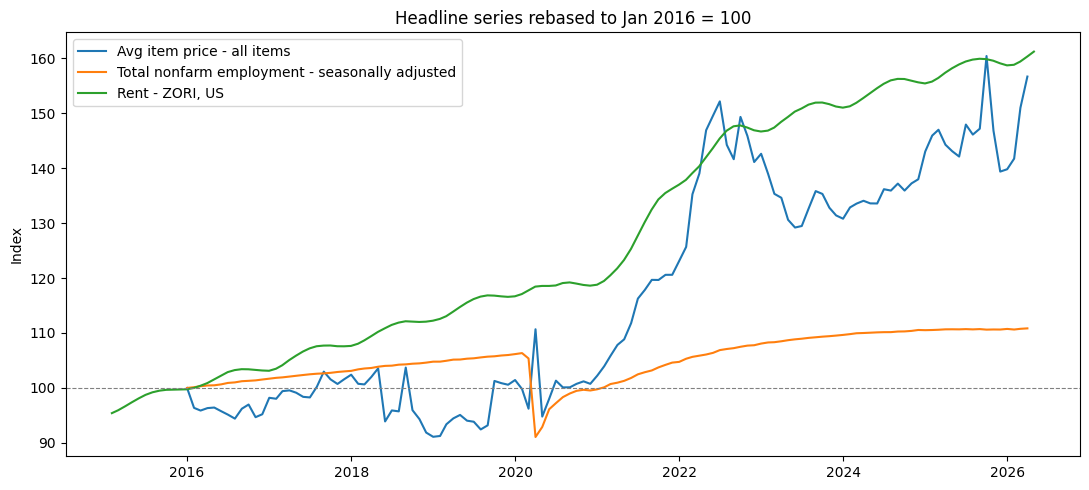

In [48]:
def rebase(df, date_col, val_col, start='2016-01-01'):
    s = df.sort_values(date_col).set_index(date_col)[val_col]
    base = s.loc[s.index >= start].iloc[0]
    return 100 * s / base

avg_price = inf_long.groupby('month')['price'].mean().reset_index()
emp_sa = earn_long[earn_long['series_id'] == 'CES0000000001']
rent_us = rent_long[rent_long['RegionName'] == 'United States']

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(rebase(avg_price, 'month', 'price'), label='Avg item price - all items')
ax.plot(rebase(emp_sa, 'month', 'employment'), label='Total nonfarm employment - seasonally adjusted')
ax.plot(rebase(rent_us, 'month', 'zori'), label='Rent - ZORI, US')
ax.axhline(100, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Headline series rebased to Jan 2016 = 100')
ax.set_ylabel('Index')
ax.legend()
fig.tight_layout()
plt.show()